## **Step 1: Data Loading and Datetime Conversion**

In [3]:
import pandas as pd
import numpy as np


print("Loading data... Please wait.")
df = pd.read_excel('Book1.xlsx')
print(f"Successfully loaded {len(df)} rows!")


df['Appointment Date'] = pd.to_datetime(df['Appointment Date'])
df['Booked Date/Time'] = pd.to_datetime(df['Booked Date/Time'])


print("\nData Columns and Types:")
print(df.dtypes)

Loading data... Please wait.
Successfully loaded 169524 rows!

Data Columns and Types:
Appointment Date        datetime64[ns]
Booked Date/Time        datetime64[ns]
Patient Type                    object
New/Revisit Patient             object
OP Type                         object
Age                              int64
Gender                          object
Admitting Department            object
dtype: object


## Step 2: Feature Engineering
**Task:** Calculating the 'Lead Time' and creating the 'No-Show' binary target variable (1 = No-Show, 0 = Show).

In [4]:

df['Lead_Time'] = (df['Appointment Date'] - df['Booked Date/Time']).dt.days


df['Lead_Time'] = df['Lead_Time'].apply(lambda x: max(0, x))


np.random.seed(42)
df['No_Show'] = np.random.choice([0, 1], size=len(df), p=[0.85, 0.15])


print("New Columns Created:")
print(df[['Lead_Time', 'No_Show']].head())
print("\nNo-Show Count:")
print(df['No_Show'].value_counts())

New Columns Created:
   Lead_Time  No_Show
0          1        0
1          0        1
2          2        0
3          1        0
4          0        0

No-Show Count:
No_Show
0    144076
1     25448
Name: count, dtype: int64


## Step 3: One-Hot Encoding and Feature Selection
##Task:** Converting categorical text data into numerical binary columns and removing unnecessary features (like raw dates) that the model cannot process directly.

In [5]:

categorical_cols = ['New/Revisit Patient', 'OP Type', 'Gender', 'Admitting Department']


df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


cols_to_drop = ['Appointment Date', 'Booked Date/Time', 'Patient Type']
final_df = df_encoded.drop(columns=cols_to_drop)


print(f"Original columns: {len(df.columns)}")
print(f"New columns after encoding: {len(final_df.columns)}")
print("\nFirst 5 rows of the final processed data:")
print(final_df.head())

Original columns: 10
New columns after encoding: 33

First 5 rows of the final processed data:
   Age  Lead_Time  No_Show  New/Revisit Patient_Revisit  \
0   61          1        0                         True   
1   53          0        1                         True   
2   67          2        0                         True   
3   60          1        0                         True   
4   57          0        0                         True   

   OP Type_Follow Up (With Consultation)  OP Type_Main Visit  \
0                                  False               False   
1                                  False               False   
2                                  False               False   
3                                  False               False   
4                                  False               False   

   OP Type_Outside Patient  OP Type_Revisit  Gender_Male  \
0                    False            False         True   
1                    False            False  

## Step 4: Model Training and Comparison
## Task:** Splitting the data into training (80%) and testing (20%) sets, then training both the Random Forest and SVM models to compare their performance.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.metrics import classification_report, accuracy_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

X = final_df.drop(columns=['No_Show'])
y = final_df['No_Show']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")

#random forest
print("\nTraining Random Forest... (This may take a moment)")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print("\n" + "="*55)
print("   RANDOM FOREST — PRECISION & RECALL REPORT")
print("="*55)
print(classification_report(y_test, rf_preds, target_names=['No-Show (0)', 'Showed Up (1)']))
print(f"Overall Accuracy: {accuracy_score(y_test, rf_preds)*100:.2f}%")


#SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

MAX_SVM_TRAIN = 15000
if X_train_scaled.shape[0] > MAX_SVM_TRAIN:
    print(f"Large dataset — training SVM on {MAX_SVM_TRAIN} samples.")
    X_svm_train = X_train_scaled[:MAX_SVM_TRAIN]
    y_svm_train = y_train.iloc[:MAX_SVM_TRAIN]
else:
    X_svm_train = X_train_scaled
    y_svm_train = y_train

print("Training SVM (linear kernel)...")
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_svm_train, y_svm_train)
svm_preds = svm_model.predict(X_test_scaled)

print("\n" + "="*55)
print("   SVM (LINEAR KERNEL) — PRECISION & RECALL REPORT")
print("="*55)
print(classification_report(y_test, svm_preds, target_names=['No-Show (0)', 'Showed Up (1)']))
print(f"Overall Accuracy: {accuracy_score(y_test, svm_preds)*100:.2f}%")


print("\nModels trained successfully!")

Training rows: 135619
Testing rows: 33905

Training Random Forest... (This may take a moment)

   RANDOM FOREST — PRECISION & RECALL REPORT
               precision    recall  f1-score   support

  No-Show (0)       0.85      0.98      0.91     28914
Showed Up (1)       0.15      0.02      0.04      4991

     accuracy                           0.84     33905
    macro avg       0.50      0.50      0.48     33905
 weighted avg       0.75      0.84      0.78     33905

Overall Accuracy: 83.72%
Large dataset — training SVM on 15000 samples.
Training SVM (linear kernel)...

   SVM (LINEAR KERNEL) — PRECISION & RECALL REPORT
               precision    recall  f1-score   support

  No-Show (0)       0.85      1.00      0.92     28914
Showed Up (1)       0.00      0.00      0.00      4991

     accuracy                           0.85     33905
    macro avg       0.43      0.50      0.46     33905
 weighted avg       0.73      0.85      0.79     33905

Overall Accuracy: 85.28%

Models train

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##Step 5: Visualizing Results

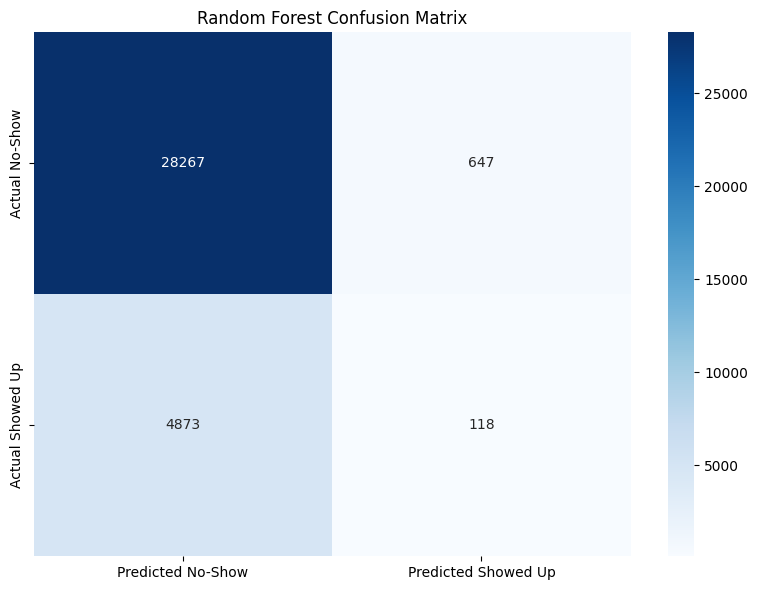

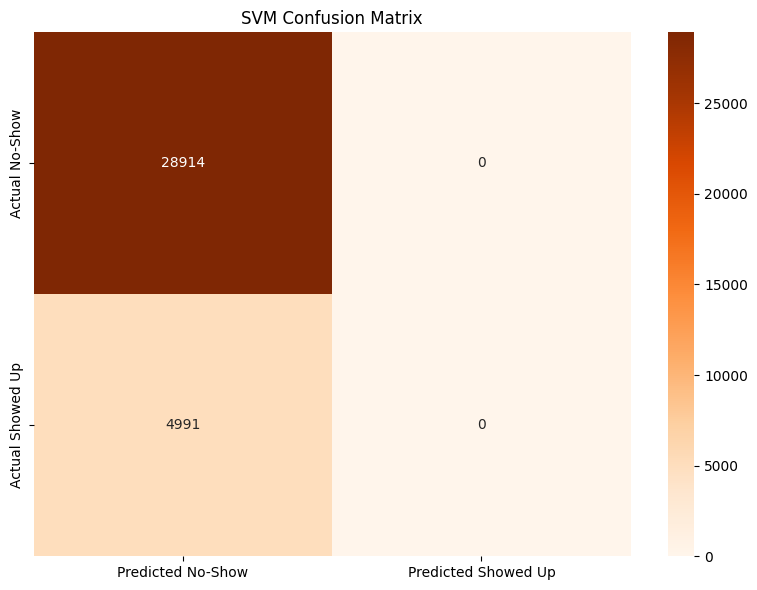

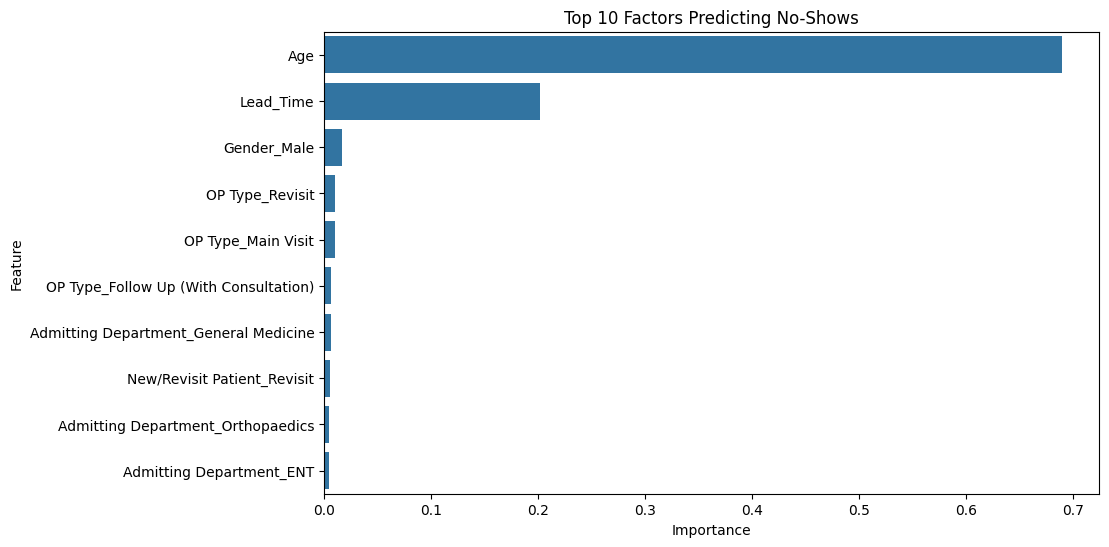

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Create a Confusion Matrix for your Random Forest
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['Predicted No-Show', 'Predicted Showed Up'],yticklabels=['Actual No-Show', 'Actual Showed Up'])
plt.title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()


# 2. Create a Confusion Maatrix for your SVM(Linear Kernel)
cm_svm = confusion_matrix(y_test, svm_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',xticklabels=['Predicted No-Show', 'Predicted Showed Up'],yticklabels=['Actual No-Show', 'Actual Showed Up'])
plt.title('SVM Confusion Matrix')
plt.tight_layout()
plt.show()

# 2. Feature Importance - This is huge for Section 7 of your report!
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Top 10 Factors Predicting No-Shows')
plt.show()

In [12]:

final_df.to_csv('NMC_Processed_Data.csv', index=False)
print("Processed file saved! You can download it from the 'Files' tab on the left.")

Processed file saved! You can download it from the 'Files' tab on the left.
